# Full-Day MLB Game Repricing Analysis

This is a walkthrough of the analysis for one full day of MLB games, with the goal of understanding the market dynamics of `KXMLBGAME`. This is a critical step before we scale to many games and many days, so we want to be very clear on the data shape, the analytical primitives, and the end-to-end process for one example. The date we are using is **May 20, 2026**. 
The goal here is to:

1. Explore the data shape and analytical primitives for `KXMLBGAME`, so we can be confident in our approach when we scale to many markets.
2. Demonstrate the data shape end-to-end (market metadata, orderbook snapshot, trade history) for one real example.
3. Establish the analytical primitives (price metrics, time alignment, drift definition) we'll reuse when we scale to many markets.
4. Cache the data to parquet so this notebook renders cleanly on GitHub even when the Snowflake warehouse is paused.

### Why `KXMLBGAME` and not the other markets

`KXMLBGAME` is the easiest market to do apples-to-apples comparison between games. The market is a binary "Will Team X win?". The other markets have `floor_strikes` that need to account for normalization and determination of price discovery. For example, some samples of the `KXMLBTOTAL` markets for CIN/PHI:

| market_ticker | floor_strike | YES meaning |
|-----------|-----------|-----------|
| KXMLBTOTAL-26MAY201305CINPHI-7 | 6.5 | Over 6.5 runs scored |
| KXMLBTOTAL-26MAY201305CINPHI-8 | 7.5 | Over 7.5 runs scored |
| KXMLBTOTAL-26MAY201305CINPHI-9 | 8.5 | Over 8.5 runs scored |

This means totals and spreads behave like strike ladders, where attention/liquidity may concentrate around the most relevant threshold. That makes them harder to compare directly without a moneyness or implied-line normalization step.

### Prerequisites

This notebook reads from the **dbt staging/marts** (`fct_markets`, `fct_market_orderbooks`, `stg_kalshi_market_trades`), not from `RAW`. If you've just scraped fresh data for this market, run `dbt run` first so the marts pick up the new rows:

```bash
dbt run --project-dir dbt --profiles-dir dbt
```

The first cell run will hit Snowflake once and write parquet to `analysis/data/full_day_2026-05-20`. Subsequent re-runs load from that cache and don't need a warm warehouse.

### Caveat
Due to an outage on May 20, 2026 (captured in https://github.com/GGarrido28/snowflake-market-data-platform/issues/81) the data set is incomplete. We have orderbook data through approximately 6:45 CDT. This means we won't be able to see the full pre-game to in-game transition for all markets, but we can still use the available data to understand the process and primitives. We will need to be mindful of this limitation as we interpret the results.

In [1]:
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import find_dotenv, load_dotenv

from market_data_platform.warehouse import SnowflakeManager
from market_data_platform.utils.timezone import utc_to_eastern

# Walk up from the notebook's cwd to find the repo root .env
load_dotenv(find_dotenv())

MARKET_DATE = "2026-05-20"
DATA_DIR = Path("data") / f"full_day_{MARKET_DATE}"

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def cached_query(query: str, name: str, snowflake: SnowflakeManager | None = None) -> pd.DataFrame:
    """Load a Snowflake query result from parquet cache if present, else query and cache.

    Keeps every notebook re-executable without warehouse access as long as the cache
    is on disk — the rendered cell output in the .ipynb is what ships to GitHub.
    """
    cache_path = DATA_DIR / f"{name}.parquet"
    if cache_path.exists():
        print(f"  loaded {name} from cache ({cache_path})")
        return pd.read_parquet(cache_path)
    if snowflake is None:
        raise RuntimeError(
            f"Cache miss for {name} and no Snowflake connection provided. "
            "Pass a SnowflakeManager to populate the cache."
        )
    print(f"  cache miss for {name}; querying Snowflake...")
    rows = snowflake.execute(query)
    df = pd.DataFrame(rows)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_path)
    print(f"  wrote {len(df)} rows to {cache_path}")
    return df

In [2]:
EVENT_CACHE_FILES = ("markets", "orderbooks", "trades")


def sql_literal(value: str) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def event_cache_dir(event_ticker: str) -> Path:
    return DATA_DIR / event_ticker


def event_cache_path(event_ticker: str, name: str) -> Path:
    return event_cache_dir(event_ticker) / f"{name}.parquet"


def missing_event_cache_files(event_ticker: str) -> list[str]:
    return [
        name
        for name in EVENT_CACHE_FILES
        if not event_cache_path(event_ticker, name).exists()
    ]


def write_event_cache(event_ticker: str, name: str, df: pd.DataFrame) -> pd.DataFrame:
    cache_path = event_cache_path(event_ticker, name)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_path)
    print(f"  wrote {event_ticker}/{name}: {len(df)} rows -> {cache_path}")
    return df


def cached_event_query(
    event_ticker: str,
    name: str,
    query: str,
    snowflake: SnowflakeManager,
) -> pd.DataFrame:
    cache_path = event_cache_path(event_ticker, name)
    if cache_path.exists():
        print(f"  loaded {event_ticker}/{name} from cache ({cache_path})")
        return pd.read_parquet(cache_path)

    print(f"  cache miss for {event_ticker}/{name}; querying Snowflake...")
    df = pd.DataFrame(snowflake.execute(query))
    return write_event_cache(event_ticker, name, df)


# Connect only when a missing cache requires Snowflake. Per dbt/macros/
# generate_schema_name.sql, staging models materialize in PROD.STAGE and mart
# models materialize in PROD.KALSHI.
snowflake = None
events_cache_path = DATA_DIR / "events.parquet"

try:
    if events_cache_path.exists():
        events_df = pd.read_parquet(events_cache_path)
        print(f"loaded events from cache ({events_cache_path})")
    else:
        snowflake = SnowflakeManager("PROD", "STAGE")
        events_query = f"""
        with mlb_events as (
            select
                event_ticker,
                try_to_date(
                    upper(substr(split_part(event_ticker, '-', 2), 1, 7)),
                    'YYMONDD'
                ) as game_date
            from PROD.STAGE.stg_kalshi_events
            where series_ticker in ('KXMLBTOTAL', 'KXMLBSPREAD', 'KXMLBGAME')
        )
        select event_ticker
        from mlb_events
        where game_date = '{MARKET_DATE}'
        order by event_ticker
        """
        events_df = pd.DataFrame(snowflake.execute(events_query))
        DATA_DIR.mkdir(parents=True, exist_ok=True)
        events_df.to_parquet(events_cache_path)
        print(f"wrote {len(events_df)} events to {events_cache_path}")

    events = events_df["event_ticker"].dropna().drop_duplicates().tolist()
    print(f"Found {len(events)} events on {MARKET_DATE}.")

    missing_events = {
        event: missing_event_cache_files(event)
        for event in events
        if missing_event_cache_files(event)
    }

    if not missing_events:
        print(
            "All per-event cache files are present. "
            "Delete an event directory or parquet file to refresh it."
        )
    else:
        if snowflake is None:
            snowflake = SnowflakeManager("PROD", "STAGE")

        print(f"Populating cache for {len(missing_events)} event(s).")
        for event, missing_names in missing_events.items():
            print(f"\n{event}: missing {', '.join(missing_names)}")
            event_sql = sql_literal(event)

            market_df = cached_event_query(
                event,
                "markets",
                f"""
                select *
                from PROD.KALSHI.fct_markets
                where event_ticker = {event_sql}
                  and series_ticker in ('KXMLBTOTAL', 'KXMLBSPREAD', 'KXMLBGAME')
                order by market_ticker
                """,
                snowflake,
            )

            market_tickers = market_df["market_ticker"].dropna().drop_duplicates().tolist()
            print(f"  found {len(market_tickers)} markets")

            if not market_tickers:
                write_event_cache(event, "orderbooks", pd.DataFrame())
                write_event_cache(event, "trades", pd.DataFrame())
                continue

            ticker_sql = ", ".join(sql_literal(ticker) for ticker in market_tickers)

            orderbook_df = cached_event_query(
                event,
                "orderbooks",
                f"""
                select *
                from PROD.KALSHI.fct_market_orderbooks
                where market_ticker in ({ticker_sql})
                order by market_ticker
                """,
                snowflake,
            )

            trades_df = cached_event_query(
                event,
                "trades",
                f"""
                select *
                from PROD.STAGE.stg_kalshi_market_trades
                where market_ticker in ({ticker_sql})
                order by market_ticker, trade_time
                """,
                snowflake,
            )

            print(
                f"  cached {len(market_df)} markets, "
                f"{len(orderbook_df)} orderbooks, {len(trades_df)} trades"
            )
finally:
    if snowflake is not None:
        snowflake.close()

loaded events from cache (data\full_day_2026-05-20\events.parquet)
Found 45 events on 2026-05-20.
All per-event cache files are present. Delete an event directory or parquet file to refresh it.


# Available Events on May 20, 2026

In [3]:
display_events = pd.DataFrame(events, columns=["market_ticker"])
display_events['series_ticker'] = display_events['market_ticker'].str.split('-').str[0]
display_events['date_time_teams'] = display_events['market_ticker'].str.split('-').str[1]
display_events['date'] = display_events['date_time_teams'].str[:7] # first 7 chars is date e.g. 26MAY10
display_events['start_time'] = display_events['date_time_teams'].str[7:11] # next 4 chars is start time e.g. 13:05 EST
display_events['teams'] = display_events['date_time_teams'].str[11:] # remaining chars is teams e.g. DETKC
display_events['start_time_est'] = pd.to_datetime(display_events['start_time'], format='%H%M').dt.time
del display_events['date_time_teams'], display_events['start_time']
display_events

,market_ticker,series_ticker,date,teams,start_time_est
0,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME,26MAY20,CINPHI,13:05:00
1,KXMLBGAME-26MAY201310BALTB,KXMLBGAME,26MAY20,BALTB,13:10:00
2,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME,26MAY20,HOUMIN,13:40:00
3,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME,26MAY20,TEXCOL,15:10:00
4,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME,26MAY20,SFAZ,15:40:00
5,KXMLBGAME-26MAY201610CWSSEA,KXMLBGAME,26MAY20,CWSSEA,16:10:00
6,KXMLBGAME-26MAY201840ATLMIA,KXMLBGAME,26MAY20,ATLMIA,18:40:00
7,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME,26MAY20,CLEDET,18:40:00
8,KXMLBGAME-26MAY201845NYMWSH,KXMLBGAME,26MAY20,NYMWSH,18:45:00
9,KXMLBGAME-26MAY201905TORNYY,KXMLBGAME,26MAY20,TORNYY,19:05:00


## Reminders

The `fct_markets` row tells us what the contract resolves on, when trading opened and closed, and the latest price snapshot at scrape time. A few Kalshi field-name conventions worth keeping in mind:

- **`_dollars`** suffix — the value is denominated in dollars (e.g. `last_price_dollars = 0.42` means the last trade cleared at 42¢).
- **`_fp`** suffix — Kalshi's "fixed-point" convention; the value is an integer count of contracts with no decimal scaling. `volume_fp` is the lifetime contract count traded.
- **`yes_*` / `no_*`** — two sides of the binary market. YES pays $1 if the market resolves true, NO pays $1 if it resolves false. Prices sum to ~$1 (modulo the bid-ask spread).

Market-level stats: 30 market tickers across 45 events on 2026-05-20.


,series_ticker,event_ticker,market_ticker,total_trades,open_yes_price,close_yes_price,average_yes_price,yes_price_delta_dollars,average_trade_size,min_trade_size,max_trade_size,orderbook_yes_implied_std_dollars,peak_trade_hour_et,peak_trade_hour_trade_count
0,KXMLBGAME,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-CIN,9311,0.43,0.99,0.661760,0.56,237.522003,0.01,50000.00,NaN,2026-05-20 14:00 EDT,2758
1,KXMLBGAME,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-PHI,8695,0.57,0.01,0.364823,-0.56,196.706822,0.01,31666.00,NaN,2026-05-20 14:00 EDT,2580
2,KXMLBGAME,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-BAL,7123,0.48,0.01,0.534707,-0.47,262.437728,0.01,78431.00,NaN,2026-05-20 15:00 EDT,2840
3,KXMLBGAME,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-TB,16724,0.53,0.99,0.496240,0.46,296.561420,0.01,35898.26,NaN,2026-05-20 15:00 EDT,4960
4,KXMLBGAME,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-HOU,4456,0.41,0.01,0.289719,-0.40,205.326313,0.02,27756.92,NaN,2026-05-20 14:00 EDT,1837
5,KXMLBGAME,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-MIN,4726,0.60,0.99,0.703034,0.39,202.320491,0.02,50000.00,NaN,2026-05-20 15:00 EDT,1491
6,KXMLBGAME,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-COL,11731,0.46,0.01,0.463273,-0.45,176.470827,0.02,20000.00,NaN,2026-05-20 17:00 EDT,5148
7,KXMLBGAME,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-TEX,22041,0.54,0.99,0.520507,0.45,225.244596,0.01,35493.74,NaN,2026-05-20 17:00 EDT,9198
8,KXMLBGAME,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-AZ,8176,0.55,0.99,0.647864,0.44,242.764329,0.01,27007.72,NaN,2026-05-20 16:00 EDT,2902
9,KXMLBGAME,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-SF,6829,0.46,0.01,0.344172,-0.45,215.992492,0.01,32622.85,NaN,2026-05-20 16:00 EDT,2796



Series-level stats: 1 series rows. Price and orderbook columns are market-level means.


,series_ticker,market_count,total_trades,open_yes_price,close_yes_price,average_yes_price,yes_price_delta_dollars,average_trade_size,min_trade_size,max_trade_size,orderbook_yes_implied_std_dollars,peak_trade_hour_et,peak_trade_hour_trade_count
0,KXMLBGAME,30,166053,0.504,0.504,0.503722,1.110223e-17,220.971011,0.01,103285.38,0.371742,2026-05-20 17:00 EDT,29386


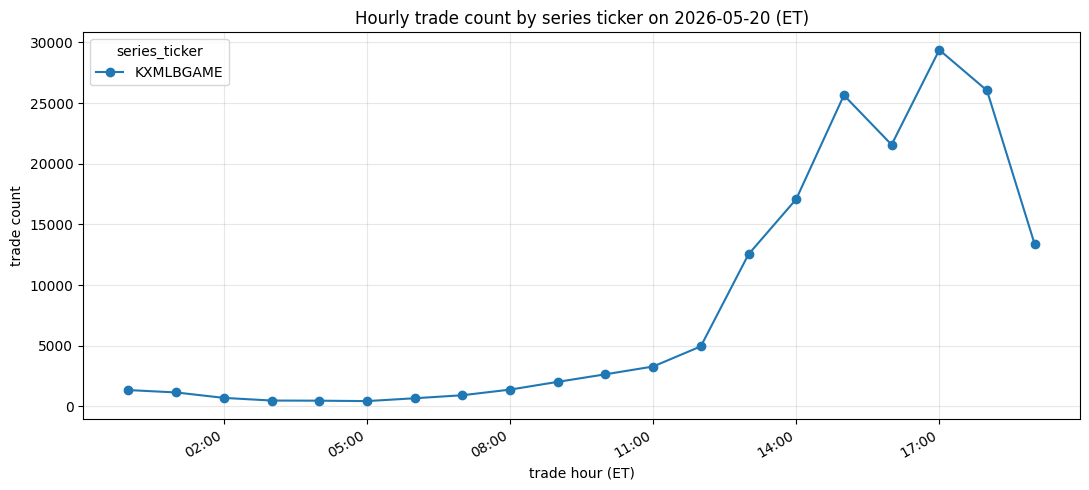

In [4]:
from IPython.display import display
from zoneinfo import ZoneInfo

import numpy as np

EASTERN = ZoneInfo('America/New_York')
analysis_date = pd.Timestamp(MARKET_DATE).date()
event_dirs = sorted(path for path in DATA_DIR.iterdir() if path.is_dir())

if not event_dirs:
    raise FileNotFoundError(f'No per-event cache directories found under {DATA_DIR}')

missing_cache_paths = [
    event_dir / f'{name}.parquet'
    for event_dir in event_dirs
    for name in EVENT_CACHE_FILES
    if not (event_dir / f'{name}.parquet').exists()
]
if missing_cache_paths:
    missing = ', '.join(str(path) for path in missing_cache_paths[:10])
    raise FileNotFoundError(f'Missing per-event cache files: {missing}')


def read_event_cache(name: str) -> pd.DataFrame:
    frames = []
    for event_dir in event_dirs:
        df = pd.read_parquet(event_dir / f'{name}.parquet').copy()
        df['cache_event_ticker'] = event_dir.name
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def coerce_numeric(df: pd.DataFrame, columns: tuple[str, ...]) -> pd.DataFrame:
    for column in columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors='coerce')
    return df


def weighted_std(values: list[float], weights: list[float]) -> float:
    value_array = np.asarray(values, dtype='float64')
    weight_array = np.asarray(weights, dtype='float64')
    if len(value_array) == 0:
        return np.nan
    if len(value_array) == 1:
        return 0.0
    if not np.isfinite(weight_array).all() or weight_array.sum() <= 0:
        return float(np.nanstd(value_array))
    average = np.average(value_array, weights=weight_array)
    variance = np.average((value_array - average) ** 2, weights=weight_array)
    return float(np.sqrt(variance))


def orderbook_yes_implied_std(orderbook_value) -> float:
    if orderbook_value is None:
        return np.nan
    if isinstance(orderbook_value, str):
        orderbook = json.loads(orderbook_value)
    elif isinstance(orderbook_value, dict):
        orderbook = orderbook_value
    else:
        return np.nan

    prices = []
    sizes = []
    for side in ('yes_dollars', 'no_dollars'):
        for level in orderbook.get(side, []) or []:
            if not level:
                continue
            price = float(level[0])
            size = float(level[1]) if len(level) > 1 else 1.0
            prices.append(1.0 - price if side == 'no_dollars' else price)
            sizes.append(size)
    return weighted_std(prices, sizes)


all_markets_df = read_event_cache('markets')
all_orderbooks_df = read_event_cache('orderbooks')
all_trades_df = read_event_cache('trades')

SERIES_TICKER = 'KXMLBGAME'

all_markets_df = all_markets_df.loc[
    all_markets_df['series_ticker'].eq(SERIES_TICKER)
].copy()
game_market_tickers = all_markets_df['market_ticker'].dropna().unique()
all_orderbooks_df = all_orderbooks_df.loc[
    all_orderbooks_df['market_ticker'].isin(game_market_tickers)
].copy()
all_trades_df = all_trades_df.loc[
    all_trades_df['market_ticker'].isin(game_market_tickers)
].copy()

all_markets_df = coerce_numeric(
    all_markets_df,
    ('last_price_dollars', 'volume_fp', 'liquidity_dollars'),
)
all_trades_df = coerce_numeric(
    all_trades_df,
    ('count_fp', 'yes_price_dollars', 'no_price_dollars'),
)

market_universe = all_markets_df.drop_duplicates('market_ticker').copy()
market_universe = market_universe[
    ['series_ticker', 'event_ticker', 'market_ticker', 'market_title', 'market_status']
]

all_trades_df['trade_time_et'] = utc_to_eastern(pd.to_datetime(all_trades_df['trade_time']))
day_trades_df = all_trades_df.loc[
    all_trades_df['trade_time_et'].dt.date == analysis_date
].copy()
day_trades_df['trade_hour_et'] = day_trades_df['trade_time_et'].dt.floor('h')

sorted_day_trades = day_trades_df.sort_values(['market_ticker', 'trade_time_et'])
trade_stats = sorted_day_trades.groupby('market_ticker', as_index=False).agg(
    total_trades=('trade_id', 'size'),
    open_yes_price=('yes_price_dollars', 'first'),
    close_yes_price=('yes_price_dollars', 'last'),
    average_yes_price=('yes_price_dollars', 'mean'),
    average_trade_size=('count_fp', 'mean'),
    min_trade_size=('count_fp', 'min'),
    max_trade_size=('count_fp', 'max'),
)

market_hourly = day_trades_df.groupby(
    ['market_ticker', 'trade_hour_et'],
    as_index=False,
).size().rename(columns={'size': 'peak_trade_hour_trade_count'})
market_peak = market_hourly.loc[
    market_hourly.groupby('market_ticker')['peak_trade_hour_trade_count'].idxmax()
].copy()
market_peak['peak_trade_hour_et'] = market_peak['trade_hour_et'].dt.strftime('%Y-%m-%d %H:%M %Z')
market_peak = market_peak[
    ['market_ticker', 'peak_trade_hour_et', 'peak_trade_hour_trade_count']
]

orderbook_stats = all_orderbooks_df.drop_duplicates('market_ticker').copy()
orderbook_stats['orderbook_yes_implied_std_dollars'] = orderbook_stats['orderbook'].apply(
    orderbook_yes_implied_std
)
orderbook_stats = orderbook_stats[
    ['market_ticker', 'orderbook_yes_implied_std_dollars']
]

market_stats = (
    market_universe
    .merge(trade_stats, on='market_ticker', how='left')
    .merge(orderbook_stats, on='market_ticker', how='left')
    .merge(market_peak, on='market_ticker', how='left')
)
market_stats['total_trades'] = market_stats['total_trades'].fillna(0).astype(int)
market_stats['yes_price_delta_dollars'] = (
    market_stats['close_yes_price'] - market_stats['open_yes_price']
)

market_stat_columns = [
    'series_ticker',
    'event_ticker',
    'market_ticker',
    'total_trades',
    'open_yes_price',
    'close_yes_price',
    'average_yes_price',
    'yes_price_delta_dollars',
    'average_trade_size',
    'min_trade_size',
    'max_trade_size',
    'orderbook_yes_implied_std_dollars',
    'peak_trade_hour_et',
    'peak_trade_hour_trade_count',
]
market_stats_display = market_stats[market_stat_columns].sort_values(
    ['series_ticker', 'event_ticker', 'market_ticker']
).reset_index(drop=True)

print(
    f'Market-level stats: {len(market_stats_display)} market tickers '
    f'across {len(event_dirs)} events on {MARKET_DATE}.'
)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(market_stats_display)

market_series = market_universe[['market_ticker', 'series_ticker']]
day_trades_with_series = day_trades_df.merge(market_series, on='market_ticker', how='left')

series_trade_stats = day_trades_with_series.groupby('series_ticker', as_index=False).agg(
    total_trades=('trade_id', 'size'),
    average_yes_price=('yes_price_dollars', 'mean'),
    average_trade_size=('count_fp', 'mean'),
    min_trade_size=('count_fp', 'min'),
    max_trade_size=('count_fp', 'max'),
)
series_market_stats = market_stats.groupby('series_ticker', as_index=False).agg(
    market_count=('market_ticker', 'nunique'),
    open_yes_price=('open_yes_price', 'mean'),
    close_yes_price=('close_yes_price', 'mean'),
    yes_price_delta_dollars=('yes_price_delta_dollars', 'mean'),
    orderbook_yes_implied_std_dollars=('orderbook_yes_implied_std_dollars', 'mean'),
)

series_hourly = day_trades_with_series.groupby(
    ['series_ticker', 'trade_hour_et'],
    as_index=False,
).size().rename(columns={'size': 'trade_count'})
series_peak = series_hourly.loc[
    series_hourly.groupby('series_ticker')['trade_count'].idxmax()
].copy()
series_peak['peak_trade_hour_et'] = series_peak['trade_hour_et'].dt.strftime('%Y-%m-%d %H:%M %Z')
series_peak = series_peak.rename(columns={'trade_count': 'peak_trade_hour_trade_count'})[
    ['series_ticker', 'peak_trade_hour_et', 'peak_trade_hour_trade_count']
]

series_stats = (
    series_market_stats
    .merge(series_trade_stats, on='series_ticker', how='left')
    .merge(series_peak, on='series_ticker', how='left')
)
series_stats['total_trades'] = series_stats['total_trades'].fillna(0).astype(int)
series_stats_display = series_stats[
    ['series_ticker', 'market_count'] + market_stat_columns[3:]
].sort_values('series_ticker').reset_index(drop=True)

print()
print(
    f'Series-level stats: {len(series_stats_display)} series rows. '
    'Price and orderbook columns are market-level means.'
)
display(series_stats_display)

if not series_hourly.empty:
    series_hourly_pivot = series_hourly.pivot(
        index='trade_hour_et',
        columns='series_ticker',
        values='trade_count',
    ).fillna(0).sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    for series_ticker in series_hourly_pivot.columns:
        ax.plot(
            series_hourly_pivot.index,
            series_hourly_pivot[series_ticker],
            marker='o',
            label=series_ticker,
        )

    ax.set_title(f'Hourly trade count by series ticker on {MARKET_DATE} (ET)')
    ax.set_xlabel('trade hour (ET)')
    ax.set_ylabel('trade count')
    ax.legend(title='series_ticker')
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3, tz=EASTERN))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=EASTERN))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


## Pregame

Using `KXMLBGAME`, we are looking to asssess the quality of the pregame market as a predictor of the eventual winner, and understand the dynamics of how the market evolves from open to first pitch. 

## Questions we are looking to answer
* Does the pregame market move toward the eventual winner before first pitch?
* Does forecast quality improve from first observed trade/open to first pitch?
* Is the improvement gradual, or concentrated near first pitch?
* Does liquidity, trade count, volume, or available order book depth correlate with smoother or more accurate pregame price discovery?

## Primary Metric

To assess the "accuracy of the pregame market, I will be using **Brier** score. A Brier score measures the accuracy of probabilistic predictions, primarily for binary or categorical outcomes (e.g., "win or no win"). It calculates the mean squared difference between the predicted probabilities and the actual outcomes, resulting in a number between \(0\) and \(1\).

```
Brier score = (predicted_probability - actual_outcome)^2
```

Lower is better. For the eventual winner, a price moving from 0.55 to 0.65 before first pitch improves the Brier score; moving from 0.55 to 0.45 worsens it. It punishes confident wrong predictions more than uncertain wrong predictions - the closer the prediction is to 1, and is wrong, the more of a penalty there is to the prediction.

In [5]:
# Build a KXMLBGAME-only pregame panel with outcome labels.
# Kalshi settlement fields in this cache are still blank, so this fixed-date
# notebook falls back to official MLB winners for the May 20, 2026 slate.
import re

KXMLBGAME_WINNER_BY_EVENT = {
    'KXMLBGAME-26MAY201305CINPHI': 'CIN',
    'KXMLBGAME-26MAY201310BALTB': 'TB',
    'KXMLBGAME-26MAY201340HOUMIN': 'MIN',
    'KXMLBGAME-26MAY201510TEXCOL': 'TEX',
    'KXMLBGAME-26MAY201540SFAZ': 'AZ',
    'KXMLBGAME-26MAY201610CWSSEA': 'SEA',
    'KXMLBGAME-26MAY201840ATLMIA': 'ATL',
    'KXMLBGAME-26MAY201840CLEDET': 'CLE',
    'KXMLBGAME-26MAY201845NYMWSH': 'WSH',
    'KXMLBGAME-26MAY201905TORNYY': 'TOR',
    'KXMLBGAME-26MAY201940BOSKC': 'BOS',
    'KXMLBGAME-26MAY201940MILCHC': 'MIL',
    'KXMLBGAME-26MAY201945PITSTL': 'PIT',
    'KXMLBGAME-26MAY202040LADSD': 'LAD',
    'KXMLBGAME-26MAY202138ATHLAA': 'ATH',
}


def parse_game_start_et(event_ticker: str) -> pd.Timestamp:
    event_key = str(event_ticker).split('-', 1)[1]
    game_start = pd.to_datetime(event_key[:11], format='%y%b%d%H%M')
    return game_start.tz_localize(EASTERN)


def normalize_result(value) -> str | None:
    if value is None or pd.isna(value):
        return None
    result = str(value).strip().lower()
    if result in {'yes', 'no'}:
        return result
    return None


def outcome_from_market_row(row: pd.Series) -> tuple[float, str]:
    market_result = normalize_result(row.get('market_result'))
    if market_result == 'yes':
        return 1.0, 'kalshi_market_result'
    if market_result == 'no':
        return 0.0, 'kalshi_market_result'

    winner_team_code = KXMLBGAME_WINNER_BY_EVENT.get(row['event_ticker'])
    if winner_team_code is None:
        return np.nan, 'missing'
    return float(row['team_code'] == winner_team_code), 'manual_mlb_result_map'


kxmlbgame_markets = all_markets_df.loc[
    all_markets_df['series_ticker'].eq('KXMLBGAME')
].drop_duplicates('market_ticker').copy()

kxmlbgame_markets = coerce_numeric(
    kxmlbgame_markets,
    (
        'last_price_dollars',
        'liquidity_dollars',
        'volume_fp',
        'yes_bid_size_fp',
        'yes_ask_size_fp',
        'yes_bid_dollars',
        'yes_ask_dollars',
    ),
)
kxmlbgame_markets['team_code'] = kxmlbgame_markets['market_ticker'].str.rsplit('-', n=1).str[-1]
kxmlbgame_markets['winner_team_code'] = kxmlbgame_markets['event_ticker'].map(KXMLBGAME_WINNER_BY_EVENT)
kxmlbgame_markets['game_start_et'] = kxmlbgame_markets['event_ticker'].apply(parse_game_start_et)

outcome_pairs = kxmlbgame_markets.apply(outcome_from_market_row, axis=1, result_type='expand')
kxmlbgame_markets['actual_outcome'] = outcome_pairs[0]
kxmlbgame_markets['outcome_source'] = outcome_pairs[1]

kxmlbgame_trades = all_trades_df.merge(
    kxmlbgame_markets[
        [
            'event_ticker',
            'market_ticker',
            'team_code',
            'winner_team_code',
            'game_start_et',
            'actual_outcome',
        ]
    ],
    on='market_ticker',
    how='inner',
    suffixes=('', '_market'),
)
kxmlbgame_trades = kxmlbgame_trades.dropna(subset=['trade_time_et', 'yes_price_dollars', 'actual_outcome']).copy()
kxmlbgame_trades['window'] = np.where(
    kxmlbgame_trades['trade_time_et'] < kxmlbgame_trades['game_start_et'],
    'pregame',
    'live',
)

pregame_trades = kxmlbgame_trades.loc[
    kxmlbgame_trades['window'].eq('pregame')
].sort_values(['market_ticker', 'trade_time_et']).copy()
pregame_trades['winner_probability'] = np.where(
    pregame_trades['actual_outcome'].eq(1.0),
    pregame_trades['yes_price_dollars'],
    1.0 - pregame_trades['yes_price_dollars'],
)
pregame_trades['brier_score'] = (
    pregame_trades['yes_price_dollars'] - pregame_trades['actual_outcome']
) ** 2

print(
    f'KXMLBGAME pregame trades: {len(pregame_trades):,} trades across '
    f'{pregame_trades["market_ticker"].nunique()} markets and '
    f'{pregame_trades["event_ticker"].nunique()} games.'
)
print('Outcome sources:')
display(kxmlbgame_markets['outcome_source'].value_counts(dropna=False).rename_axis('source').reset_index(name='markets'))


KXMLBGAME pregame trades: 44,484 trades across 30 markets and 15 games.
Outcome sources:


,source,markets
0,manual_mlb_result_map,30


In [6]:
# Answer 1 and 2: did pregame prices move toward the eventual winner,
# and did Brier forecast quality improve from first observed trade to first pitch?
def summarize_pregame_market(group: pd.DataFrame) -> pd.Series:
    group = group.sort_values('trade_time_et').copy()
    first = group.iloc[0]
    last = group.iloc[-1]
    winner_prob_path = group['winner_probability']
    total_abs_winner_prob_move = winner_prob_path.diff().abs().sum()
    net_winner_prob_change = last['winner_probability'] - first['winner_probability']
    elapsed_hours = (last['trade_time_et'] - first['trade_time_et']).total_seconds() / 3600

    if group['trade_time_et'].nunique() > 1:
        hours_from_first = (
            group['trade_time_et'] - group['trade_time_et'].min()
        ).dt.total_seconds() / 3600
        winner_prob_slope_per_hour = np.polyfit(hours_from_first, winner_prob_path, 1)[0]
    else:
        winner_prob_slope_per_hour = np.nan

    return pd.Series(
        {
            'event_ticker': first['event_ticker'],
            'team_code': first['team_code'],
            'winner_team_code': first['winner_team_code'],
            'actual_outcome': first['actual_outcome'],
            'first_trade_et': first['trade_time_et'],
            'last_pregame_trade_et': last['trade_time_et'],
            'game_start_et': first['game_start_et'],
            'hours_observed_pregame': elapsed_hours,
            'pregame_trade_count': len(group),
            'pregame_volume': group['count_fp'].sum(),
            'open_yes_price': first['yes_price_dollars'],
            'first_pitch_yes_price': last['yes_price_dollars'],
            'yes_price_change': last['yes_price_dollars'] - first['yes_price_dollars'],
            'winner_prob_open': first['winner_probability'],
            'winner_prob_first_pitch': last['winner_probability'],
            'winner_prob_change': net_winner_prob_change,
            'moved_toward_winner': net_winner_prob_change > 0,
            'brier_open': first['brier_score'],
            'brier_first_pitch': last['brier_score'],
            'brier_improvement': first['brier_score'] - last['brier_score'],
            'forecast_improved': first['brier_score'] > last['brier_score'],
            'total_abs_winner_prob_move': total_abs_winner_prob_move,
            'path_efficiency': (
                abs(net_winner_prob_change) / total_abs_winner_prob_move
                if total_abs_winner_prob_move > 0
                else np.nan
            ),
            'winner_prob_slope_per_hour': winner_prob_slope_per_hour,
        }
    )


pregame_market_summary = pd.DataFrame(
    [
        summarize_pregame_market(group).rename(market_ticker)
        for market_ticker, group in pregame_trades.groupby('market_ticker')
    ]
).rename_axis('market_ticker').reset_index()

market_context_cols = [
    'market_ticker',
    'market_title',
    'market_status',
    'last_price_dollars',
    'volume_fp',
    'liquidity_dollars',
    'yes_bid_dollars',
    'yes_ask_dollars',
    'yes_bid_size_fp',
    'yes_ask_size_fp',
    'outcome_source',
]
pregame_market_summary = pregame_market_summary.merge(
    kxmlbgame_markets[[c for c in market_context_cols if c in kxmlbgame_markets.columns]],
    on='market_ticker',
    how='left',
)

pregame_event_summary = pregame_market_summary.groupby('event_ticker', as_index=False).agg(
    winner_team_code=('winner_team_code', 'first'),
    markets=('market_ticker', 'nunique'),
    pregame_trade_count=('pregame_trade_count', 'sum'),
    pregame_volume=('pregame_volume', 'sum'),
    mean_winner_prob_open=('winner_prob_open', 'mean'),
    mean_winner_prob_first_pitch=('winner_prob_first_pitch', 'mean'),
    mean_winner_prob_change=('winner_prob_change', 'mean'),
    mean_brier_open=('brier_open', 'mean'),
    mean_brier_first_pitch=('brier_first_pitch', 'mean'),
    mean_brier_improvement=('brier_improvement', 'mean'),
    mean_path_efficiency=('path_efficiency', 'mean'),
)
pregame_event_summary['forecast_improved'] = pregame_event_summary['mean_brier_improvement'] > 0
pregame_event_summary['moved_toward_winner'] = pregame_event_summary['mean_winner_prob_change'] > 0

answer_summary = pd.DataFrame(
    [
        {
            'question': 'Markets moved toward eventual winner',
            'yes_count': int(pregame_market_summary['moved_toward_winner'].sum()),
            'total': len(pregame_market_summary),
            'share': pregame_market_summary['moved_toward_winner'].mean(),
        },
        {
            'question': 'Markets improved Brier score',
            'yes_count': int(pregame_market_summary['forecast_improved'].sum()),
            'total': len(pregame_market_summary),
            'share': pregame_market_summary['forecast_improved'].mean(),
        },
        {
            'question': 'Games moved toward eventual winner',
            'yes_count': int(pregame_event_summary['moved_toward_winner'].sum()),
            'total': len(pregame_event_summary),
            'share': pregame_event_summary['moved_toward_winner'].mean(),
        },
        {
            'question': 'Games improved mean Brier score',
            'yes_count': int(pregame_event_summary['forecast_improved'].sum()),
            'total': len(pregame_event_summary),
            'share': pregame_event_summary['forecast_improved'].mean(),
        },
    ]
)

print('Pregame directional and Brier answers')
display(answer_summary)

market_display_cols = [
    'event_ticker',
    'market_ticker',
    'team_code',
    'winner_team_code',
    'pregame_trade_count',
    'open_yes_price',
    'first_pitch_yes_price',
    'winner_prob_open',
    'winner_prob_first_pitch',
    'winner_prob_change',
    'brier_open',
    'brier_first_pitch',
    'brier_improvement',
    'path_efficiency',
]
print('Market-level pregame summary')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(
        pregame_market_summary[market_display_cols]
        .sort_values(['event_ticker', 'team_code'])
        .reset_index(drop=True)
    )

print('Game-level pregame summary (averaging the two complementary team contracts)')
display(
    pregame_event_summary.sort_values('mean_brier_improvement', ascending=False).reset_index(drop=True)
)


Pregame directional and Brier answers


,question,yes_count,total,share
0,Markets moved toward eventual winner,14,30,0.466667
1,Markets improved Brier score,14,30,0.466667
2,Games moved toward eventual winner,5,15,0.333333
3,Games improved mean Brier score,6,15,0.400000


Market-level pregame summary


,event_ticker,market_ticker,team_code,winner_team_code,pregame_trade_count,open_yes_price,first_pitch_yes_price,winner_prob_open,winner_prob_first_pitch,winner_prob_change,brier_open,brier_first_pitch,brier_improvement,path_efficiency
0,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-CIN,CIN,CIN,1748,0.38,0.42,0.38,0.42,0.04,0.3844,0.3364,0.0480,0.037736
1,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-PHI,PHI,CIN,1916,0.62,0.59,0.38,0.41,0.03,0.3844,0.3481,0.0363,0.020690
2,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-BAL,BAL,TB,990,0.46,0.49,0.54,0.51,-0.03,0.2116,0.2401,-0.0285,0.026087
3,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-TB,TB,TB,5262,0.52,0.53,0.52,0.53,0.01,0.2304,0.2209,0.0095,0.005076
4,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-HOU,HOU,MIN,820,0.40,0.44,0.60,0.56,-0.04,0.1600,0.1936,-0.0336,0.105263
5,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-MIN,MIN,MIN,1537,0.61,0.57,0.61,0.57,-0.04,0.1521,0.1849,-0.0328,0.066667
6,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-COL,COL,TEX,455,0.48,0.47,0.52,0.53,0.01,0.2304,0.2209,0.0095,0.014493
7,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-TEX,TEX,TEX,1975,0.55,0.54,0.55,0.54,-0.01,0.2025,0.2116,-0.0091,0.009901
8,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-AZ,AZ,AZ,1264,0.54,0.51,0.54,0.51,-0.03,0.2116,0.2401,-0.0285,0.049180
9,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-SF,SF,AZ,820,0.48,0.50,0.52,0.50,-0.02,0.2304,0.2500,-0.0196,0.022727


Game-level pregame summary (averaging the two complementary team contracts)


,event_ticker,winner_team_code,markets,pregame_trade_count,pregame_volume,mean_winner_prob_open,mean_winner_prob_first_pitch,mean_winner_prob_change,mean_brier_open,mean_brier_first_pitch,mean_brier_improvement,mean_path_efficiency,forecast_improved,moved_toward_winner
0,KXMLBGAME-26MAY202040LADSD,LAD,2,3859,400350.55,0.575,0.640,0.065,0.18065,0.12970,0.05095,0.039700,True,True
1,KXMLBGAME-26MAY201840CLEDET,CLE,2,2295,393850.57,0.480,0.525,0.045,0.27040,0.22565,0.04475,0.023551,True,True
2,KXMLBGAME-26MAY201305CINPHI,CIN,2,3664,746237.58,0.380,0.415,0.035,0.38440,0.34225,0.04215,0.029213,True,True
3,KXMLBGAME-26MAY201945PITSTL,PIT,2,2116,310131.23,0.470,0.485,0.015,0.28090,0.26525,0.01565,0.027661,True,True
4,KXMLBGAME-26MAY202138ATHLAA,ATH,2,2202,526728.72,0.525,0.540,0.015,0.22565,0.21170,0.01395,0.008197,True,True
5,KXMLBGAME-26MAY201510TEXCOL,TEX,2,2430,493021.56,0.535,0.535,0.000,0.21645,0.21625,0.00020,0.012197,True,False
6,KXMLBGAME-26MAY201905TORNYY,TOR,2,2653,318815.25,0.385,0.385,0.000,0.37825,0.37825,0.00000,0.013738,False,False
7,KXMLBGAME-26MAY201940MILCHC,MIL,2,3774,776065.94,0.500,0.490,-0.010,0.26000,0.26020,-0.00020,0.082079,False,False
8,KXMLBGAME-26MAY201610CWSSEA,SEA,2,2346,360612.51,0.575,0.565,-0.010,0.18065,0.18925,-0.00860,0.018331,False,False
9,KXMLBGAME-26MAY201310BALTB,TB,2,6252,2406806.32,0.530,0.520,-0.010,0.22100,0.23050,-0.00950,0.015582,False,False


Pregame Brier path by checkpoint


,checkpoint_order,checkpoint,markets,mean_winner_probability,median_winner_probability,mean_brier_score,median_brier_score
0,0,first_observed,30,0.515000,0.520,0.241023,0.23040
1,1,6h_before,30,0.524333,0.535,0.231323,0.21625
2,2,3h_before,30,0.520667,0.530,0.234513,0.22090
3,3,1h_before,30,0.518000,0.520,0.236927,0.23040
4,4,15m_before,30,0.516667,0.520,0.238007,0.23040
5,5,first_pitch,30,0.516000,0.515,0.238713,0.23525


Among markets with positive pregame Brier improvement, median share of that improvement occurring in the final hour: 0.00%
Median market path efficiency: 2.36%


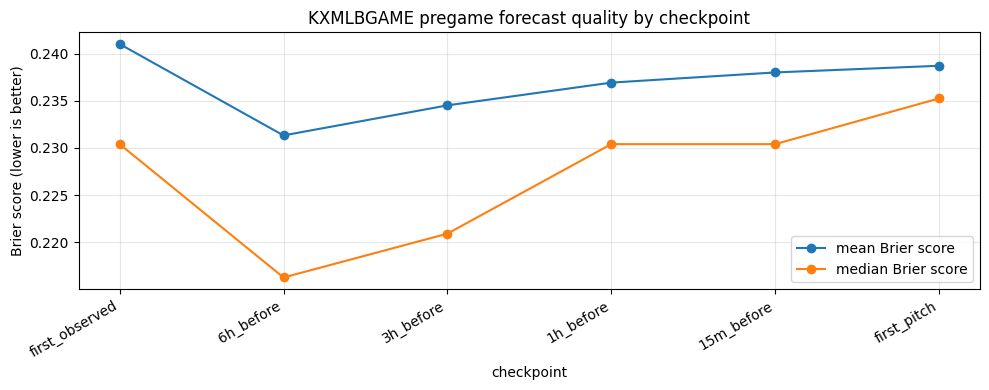

Final-hour concentration detail


,event_ticker,market_ticker,team_code,winner_team_code,total_brier_improvement,final_hour_brier_improvement,final_hour_share_of_positive_improvement,total_winner_prob_change,final_hour_winner_prob_change
0,KXMLBGAME-26MAY201940MILCHC,KXMLBGAME-26MAY201940MILCHC-MIL,MIL,MIL,0.1100,0.0101,0.091818,0.10,0.01
1,KXMLBGAME-26MAY202040LADSD,KXMLBGAME-26MAY202040LADSD-LAD,LAD,LAD,0.0624,0.0000,0.000000,0.08,0.00
2,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME-26MAY201840CLEDET-CLE,CLE,CLE,0.0495,0.0000,0.000000,0.05,0.00
3,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-CIN,CIN,CIN,0.0480,-0.0115,-0.239583,0.04,-0.01
4,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME-26MAY201840CLEDET-DET,DET,CLE,0.0400,0.0000,0.000000,0.04,0.00
5,KXMLBGAME-26MAY202040LADSD,KXMLBGAME-26MAY202040LADSD-SD,SD,LAD,0.0395,0.0000,0.000000,0.05,0.00
6,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-PHI,PHI,CIN,0.0363,-0.0117,-0.322314,0.03,-0.01
7,KXMLBGAME-26MAY202138ATHLAA,KXMLBGAME-26MAY202138ATHLAA-ATH,ATH,ATH,0.0279,0.0000,0.000000,0.03,0.00
8,KXMLBGAME-26MAY201945PITSTL,KXMLBGAME-26MAY201945PITSTL-PIT,PIT,PIT,0.0208,0.0000,0.000000,0.02,0.00
9,KXMLBGAME-26MAY201905TORNYY,KXMLBGAME-26MAY201905TORNYY-TOR,TOR,TOR,0.0123,0.0000,0.000000,0.01,0.00


In [7]:
# Answer 3: is improvement gradual, or concentrated near first pitch?
CHECKPOINTS = [
    ('first_observed', None),
    ('6h_before', pd.Timedelta(hours=6)),
    ('3h_before', pd.Timedelta(hours=3)),
    ('1h_before', pd.Timedelta(hours=1)),
    ('15m_before', pd.Timedelta(minutes=15)),
    ('first_pitch', pd.Timedelta(0)),
]

checkpoint_rows = []
for market_ticker, group in pregame_trades.groupby('market_ticker'):
    group = group.sort_values('trade_time_et')
    first = group.iloc[0]
    for checkpoint_order, (checkpoint, offset) in enumerate(CHECKPOINTS):
        if offset is None:
            selected = first
            checkpoint_time = first['trade_time_et']
        else:
            checkpoint_time = first['game_start_et'] - offset
            eligible = group.loc[group['trade_time_et'] <= checkpoint_time]
            if eligible.empty:
                continue
            selected = eligible.iloc[-1]

        checkpoint_rows.append(
            {
                'event_ticker': first['event_ticker'],
                'market_ticker': market_ticker,
                'team_code': first['team_code'],
                'winner_team_code': first['winner_team_code'],
                'actual_outcome': first['actual_outcome'],
                'checkpoint': checkpoint,
                'checkpoint_order': checkpoint_order,
                'checkpoint_time_et': checkpoint_time,
                'observed_trade_time_et': selected['trade_time_et'],
                'yes_price': selected['yes_price_dollars'],
                'winner_probability': selected['winner_probability'],
                'brier_score': selected['brier_score'],
            }
        )

pregame_checkpoint_prices = pd.DataFrame(checkpoint_rows)
checkpoint_summary = pregame_checkpoint_prices.groupby(
    ['checkpoint_order', 'checkpoint'],
    as_index=False,
).agg(
    markets=('market_ticker', 'nunique'),
    mean_winner_probability=('winner_probability', 'mean'),
    median_winner_probability=('winner_probability', 'median'),
    mean_brier_score=('brier_score', 'mean'),
    median_brier_score=('brier_score', 'median'),
)

checkpoint_brier_wide = pregame_checkpoint_prices.pivot_table(
    index='market_ticker',
    columns='checkpoint',
    values='brier_score',
    aggfunc='last',
)
checkpoint_prob_wide = pregame_checkpoint_prices.pivot_table(
    index='market_ticker',
    columns='checkpoint',
    values='winner_probability',
    aggfunc='last',
)

concentration = pregame_market_summary[['market_ticker', 'event_ticker', 'team_code', 'winner_team_code']].copy()
concentration = concentration.merge(
    checkpoint_brier_wide.add_prefix('brier_'),
    left_on='market_ticker',
    right_index=True,
    how='left',
).merge(
    checkpoint_prob_wide.add_prefix('winner_prob_'),
    left_on='market_ticker',
    right_index=True,
    how='left',
)
concentration['total_brier_improvement'] = (
    concentration['brier_first_observed'] - concentration['brier_first_pitch']
)
concentration['final_hour_brier_improvement'] = (
    concentration['brier_1h_before'] - concentration['brier_first_pitch']
)
concentration['final_hour_share_of_positive_improvement'] = np.where(
    concentration['total_brier_improvement'] > 0,
    concentration['final_hour_brier_improvement'] / concentration['total_brier_improvement'],
    np.nan,
)
concentration['total_winner_prob_change'] = (
    concentration['winner_prob_first_pitch'] - concentration['winner_prob_first_observed']
)
concentration['final_hour_winner_prob_change'] = (
    concentration['winner_prob_first_pitch'] - concentration['winner_prob_1h_before']
)

print('Pregame Brier path by checkpoint')
display(checkpoint_summary)

positive_improvement = concentration.loc[concentration['total_brier_improvement'] > 0]
print(
    'Among markets with positive pregame Brier improvement, median share of that '
    f'improvement occurring in the final hour: '
    f'{positive_improvement["final_hour_share_of_positive_improvement"].median():.2%}'
)
print(
    'Median market path efficiency: '
    f'{pregame_market_summary["path_efficiency"].median():.2%}'
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    checkpoint_summary['checkpoint'],
    checkpoint_summary['mean_brier_score'],
    marker='o',
    label='mean Brier score',
)
ax.plot(
    checkpoint_summary['checkpoint'],
    checkpoint_summary['median_brier_score'],
    marker='o',
    label='median Brier score',
)
ax.set_title('KXMLBGAME pregame forecast quality by checkpoint')
ax.set_xlabel('checkpoint')
ax.set_ylabel('Brier score (lower is better)')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Final-hour concentration detail')
display(
    concentration[
        [
            'event_ticker',
            'market_ticker',
            'team_code',
            'winner_team_code',
            'total_brier_improvement',
            'final_hour_brier_improvement',
            'final_hour_share_of_positive_improvement',
            'total_winner_prob_change',
            'final_hour_winner_prob_change',
        ]
    ].sort_values('total_brier_improvement', ascending=False).reset_index(drop=True)
)


Spearman correlations are directional diagnostics, not causal claims. The orderbook fields are scrape-time snapshots, not historical pregame depth.


,metric,feature,spearman_corr,n_markets
0,brier_improvement,orderbook_total_depth_contracts,0.343054,30
1,brier_improvement,orderbook_yes_depth_contracts,0.326959,30
2,brier_improvement,orderbook_no_depth_contracts,0.313163,30
3,brier_improvement,pregame_trade_count,0.290387,30
4,brier_improvement,yes_bid_size_fp,0.128157,30
5,brier_improvement,pregame_volume,0.052509,30
6,brier_improvement,yes_ask_size_fp,0.003337,30
7,brier_improvement,volume_fp,-0.067416,30
8,brier_improvement,liquidity_dollars,NaN,30
9,path_efficiency,yes_bid_size_fp,0.179978,30


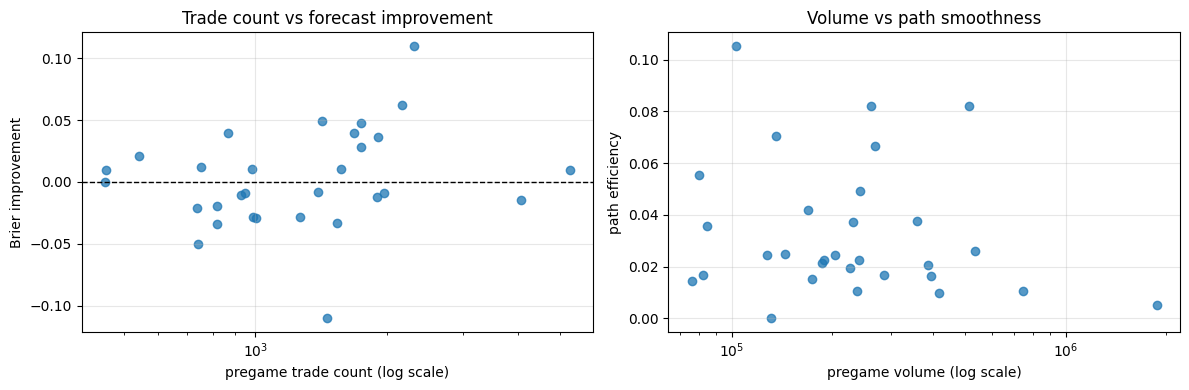

Liquidity/path diagnostic panel


,event_ticker,market_ticker,team_code,winner_team_code,pregame_trade_count,pregame_volume,brier_improvement,winner_prob_change,path_efficiency,volume_fp,liquidity_dollars,orderbook_total_depth_contracts
0,KXMLBGAME-26MAY201940MILCHC,KXMLBGAME-26MAY201940MILCHC-MIL,MIL,MIL,2311,513883.25,0.1100,0.10,0.081967,68119.26,0.0,2430619.37
1,KXMLBGAME-26MAY202040LADSD,KXMLBGAME-26MAY202040LADSD-LAD,LAD,LAD,2171,231347.94,0.0624,0.08,0.037383,117685.05,0.0,4819309.60
2,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME-26MAY201840CLEDET-CLE,CLE,CLE,1426,204520.00,0.0495,0.05,0.024631,31982.50,0.0,752973.38
3,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-CIN,CIN,CIN,1748,359644.53,0.0480,0.04,0.037736,1890936.07,0.0,0.00
4,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME-26MAY201840CLEDET-DET,DET,CLE,869,189330.57,0.0400,0.04,0.022472,19965.72,0.0,759956.31
5,KXMLBGAME-26MAY202040LADSD,KXMLBGAME-26MAY202040LADSD-SD,SD,LAD,1688,169002.61,0.0395,0.05,0.042017,71717.49,0.0,4780491.65
6,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-PHI,PHI,CIN,1916,386593.05,0.0363,0.03,0.020690,1445538.55,0.0,0.00
7,KXMLBGAME-26MAY202138ATHLAA,KXMLBGAME-26MAY202138ATHLAA-ATH,ATH,ATH,1749,395142.54,0.0279,0.03,0.016393,220719.01,0.0,3638659.91
8,KXMLBGAME-26MAY201945PITSTL,KXMLBGAME-26MAY201945PITSTL-PIT,PIT,PIT,543,84161.04,0.0208,0.02,0.035714,22670.70,0.0,1956335.29
9,KXMLBGAME-26MAY201905TORNYY,KXMLBGAME-26MAY201905TORNYY-TOR,TOR,TOR,750,82214.93,0.0123,0.01,0.016949,19302.85,0.0,307461.72


In [8]:
# Answer 4: do liquidity, trade count, volume, or order book depth correlate
# with smoother or more accurate pregame price discovery?
def orderbook_depth_summary(orderbook_value) -> pd.Series:
    if orderbook_value is None:
        return pd.Series(
            {
                'orderbook_yes_depth_contracts': np.nan,
                'orderbook_no_depth_contracts': np.nan,
                'orderbook_total_depth_contracts': np.nan,
                'best_yes_bid': np.nan,
                'best_no_bid': np.nan,
            }
        )
    if isinstance(orderbook_value, str):
        orderbook = json.loads(orderbook_value)
    elif isinstance(orderbook_value, dict):
        orderbook = orderbook_value
    else:
        return pd.Series(
            {
                'orderbook_yes_depth_contracts': np.nan,
                'orderbook_no_depth_contracts': np.nan,
                'orderbook_total_depth_contracts': np.nan,
                'best_yes_bid': np.nan,
                'best_no_bid': np.nan,
            }
        )

    yes_levels = orderbook.get('yes_dollars') or []
    no_levels = orderbook.get('no_dollars') or []
    yes_depth = sum(float(level[1]) for level in yes_levels if len(level) > 1)
    no_depth = sum(float(level[1]) for level in no_levels if len(level) > 1)
    best_yes_bid = max((float(level[0]) for level in yes_levels), default=np.nan)
    best_no_bid = max((float(level[0]) for level in no_levels), default=np.nan)
    return pd.Series(
        {
            'orderbook_yes_depth_contracts': yes_depth,
            'orderbook_no_depth_contracts': no_depth,
            'orderbook_total_depth_contracts': yes_depth + no_depth,
            'best_yes_bid': best_yes_bid,
            'best_no_bid': best_no_bid,
        }
    )


kxmlbgame_orderbook_context = all_orderbooks_df.loc[
    all_orderbooks_df['market_ticker'].isin(kxmlbgame_markets['market_ticker'])
].drop_duplicates('market_ticker').copy()
orderbook_depth = kxmlbgame_orderbook_context['orderbook'].apply(orderbook_depth_summary)
kxmlbgame_orderbook_context = pd.concat(
    [kxmlbgame_orderbook_context[['market_ticker']], orderbook_depth],
    axis=1,
)

liquidity_analysis = pregame_market_summary.merge(
    kxmlbgame_orderbook_context,
    on='market_ticker',
    how='left',
)

metric_cols = [
    'brier_improvement',
    'winner_prob_change',
    'path_efficiency',
    'winner_prob_slope_per_hour',
]
feature_cols = [
    'pregame_trade_count',
    'pregame_volume',
    'volume_fp',
    'liquidity_dollars',
    'yes_bid_size_fp',
    'yes_ask_size_fp',
    'orderbook_yes_depth_contracts',
    'orderbook_no_depth_contracts',
    'orderbook_total_depth_contracts',
]

correlation_rows = []
for metric in metric_cols:
    for feature in feature_cols:
        if metric not in liquidity_analysis.columns or feature not in liquidity_analysis.columns:
            continue
        valid = liquidity_analysis[[metric, feature]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) < 3 or valid[feature].nunique() < 2 or valid[metric].nunique() < 2:
            spearman_corr = np.nan
        else:
            ranked = valid.rank(method='average')
            spearman_corr = ranked[feature].corr(ranked[metric])
        correlation_rows.append(
            {
                'metric': metric,
                'feature': feature,
                'spearman_corr': spearman_corr,
                'n_markets': len(valid),
            }
        )

pregame_liquidity_correlations = pd.DataFrame(correlation_rows)

print(
    'Spearman correlations are directional diagnostics, not causal claims. '
    'The orderbook fields are scrape-time snapshots, not historical pregame depth.'
)
display(
    pregame_liquidity_correlations
    .sort_values(['metric', 'spearman_corr'], ascending=[True, False])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(
    liquidity_analysis['pregame_trade_count'],
    liquidity_analysis['brier_improvement'],
    alpha=0.75,
)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xscale('log')
axes[0].set_xlabel('pregame trade count (log scale)')
axes[0].set_ylabel('Brier improvement')
axes[0].set_title('Trade count vs forecast improvement')

axes[1].scatter(
    liquidity_analysis['pregame_volume'],
    liquidity_analysis['path_efficiency'],
    alpha=0.75,
)
axes[1].set_xscale('log')
axes[1].set_xlabel('pregame volume (log scale)')
axes[1].set_ylabel('path efficiency')
axes[1].set_title('Volume vs path smoothness')

plt.tight_layout()
plt.show()

liquidity_display_cols = [
    'event_ticker',
    'market_ticker',
    'team_code',
    'winner_team_code',
    'pregame_trade_count',
    'pregame_volume',
    'brier_improvement',
    'winner_prob_change',
    'path_efficiency',
    'volume_fp',
    'liquidity_dollars',
    'orderbook_total_depth_contracts',
]
print('Liquidity/path diagnostic panel')
display(
    liquidity_analysis[[c for c in liquidity_display_cols if c in liquidity_analysis.columns]]
    .sort_values('brier_improvement', ascending=False)
    .reset_index(drop=True)
)
